Task
First load the dataset in a notebook and preprocess it. Then use visualisations to address the following questions:

Which states have the most sales?
What is the difference between New York and California in terms of sales and profit? (Compare the total sales and profit between New York and California.)
Who is an outstanding customer in New York?
Are there any differences among states in profitability?
The Pareto Principle, also known as the 80/20 rule, is a concept derived from the work of Italian economist Vilfredo Pareto. It states that roughly 80% of the effects come from 20% of the causes. For instance, identifying the top 20% of products that generate 80% of sales or the top 20% of customers that contribute to 80% of profit can help in prioritizing efforts and resources. This focus can lead to improved efficiency and effectiveness in business strategies. Can we apply Pareto principle to customers and Profit ? (Determine if 20% of the customers contribute to 80% of the profit.)
What are the Top 20 cities by Sales ? What about the Top 20 cities by Profit ? Are there any difference among cities in profitability ? (Identify the top 20 cities based on total sales and total profit and analyze differences in profitability among these cities.)
What are the Top 20 customers by Sales?
Plot the Cumulative curve in Sales by Customers. Can we apply Pareto principle to customers and Sales ?
Based on the analysis, make decisions on which states and cities to prioritize for marketing strategies.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('US Superstore data.xls') # Loading the data frame from Excel file

# Exploring the data frame, this shows that there are no missing entries.

print("Shape:", df.shape)
print("\nFirst rows:\n", df.head())
print("\nInfo:\n", df.info())
print("\nMissing values:\n", df.isnull().sum())

# Check for duplicate rows, no duplicate rows found.

print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()




Shape: (9994, 21)

First rows:
    Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \


Sales by State:
State
Alabama                  19510.6400
Arizona                  35282.0010
Arkansas                 11678.1300
California              457687.6315
Colorado                 32108.1180
Connecticut              13384.3570
Delaware                 27451.0690
District of Columbia      2865.0200
Florida                  89473.7080
Georgia                  49095.8400
Idaho                     4382.4860
Illinois                 80166.1010
Indiana                  53555.3600
Iowa                      4579.7600
Kansas                    2914.3100
Kentucky                 36591.7500
Louisiana                 9217.0300
Maine                     1270.5300
Maryland                 23705.5230
Massachusetts            28634.4340
Michigan                 76269.6140
Minnesota                29863.1500
Mississippi              10771.3400
Missouri                 22205.1500
Montana                   5589.3520
Nebraska                  7464.9300
Nevada                   16729.1020
New Ha

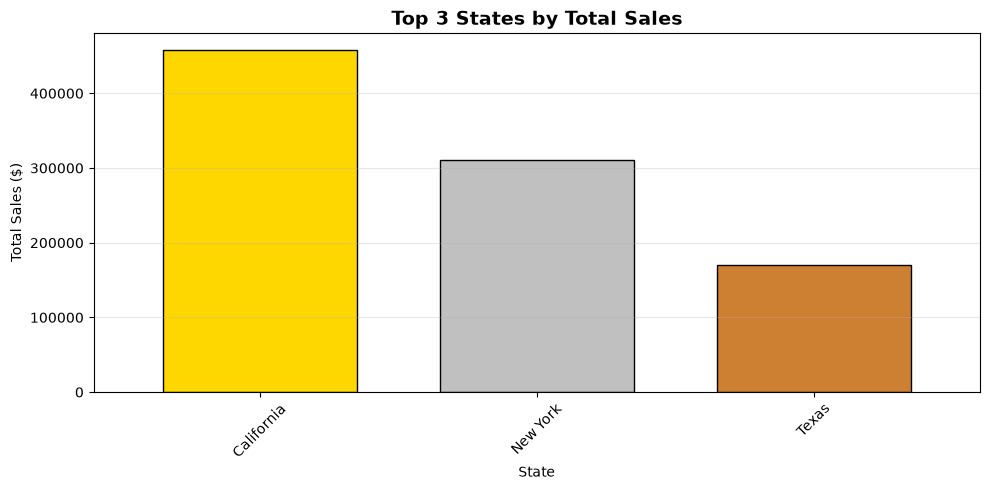

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

sales_by_state = df.groupby('State')['Sales'].sum()

print("Sales by State:")
print(sales_by_state)

max_sales = sales_by_state.max()
print(f"\nMaximum sales amount: ${max_sales:,.2f}")


# Find which state has the maximum sales
state_with_max_sales = sales_by_state.idxmax()
print(f"State with most sales: {state_with_max_sales}")

sales_by_state_sorted = sales_by_state.sort_values(ascending=False)

top_3 = sales_by_state.sort_values(ascending=False).head(3)

print("TOP 3 STATES BY SALES:")
print("=" * 50)
for rank, (state, sales) in enumerate(top_3.items(), 1):
    print(f"{rank}. {state}: ${sales:,.2f}")

# Visualize top 3
plt.figure(figsize=(10, 5))
top_3.plot(kind='bar', color=['gold', 'silver', '#CD7F32'], edgecolor='black', width=0.7)
plt.title('Top 3 States by Total Sales', fontsize=14, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# Find which state has the maximum sales
state_with_max_sales = sales_by_state.idxmax()
print(f"State with most sales: {state_with_max_sales}")

State with most sales: California


In [11]:
df = pd.read_excel('US Superstore data.xls')

# Filter data for each state
ny_sales = df[df['State'] == 'New York']['Sales'].sum()
ny_profit = df[df['State'] == 'New York']['Profit'].sum()

# Compare New York and California, get all rows per state.
ny_data = df[df['State'] == 'New York']
ca_data = df[df['State'] == 'California']

# Get the sum of all sales per state.
ny_sales = ny_data['Sales'].sum()
ny_profit = ny_data['Profit'].sum()

ca_sales = ca_data['Sales'].sum()
ca_profit = ca_data['Profit'].sum()

# Calculate the differences for sales and profit.
sales_difference = ca_sales - ny_sales
profit_difference = ca_profit - ny_profit

Visualize the New York and California comparison.

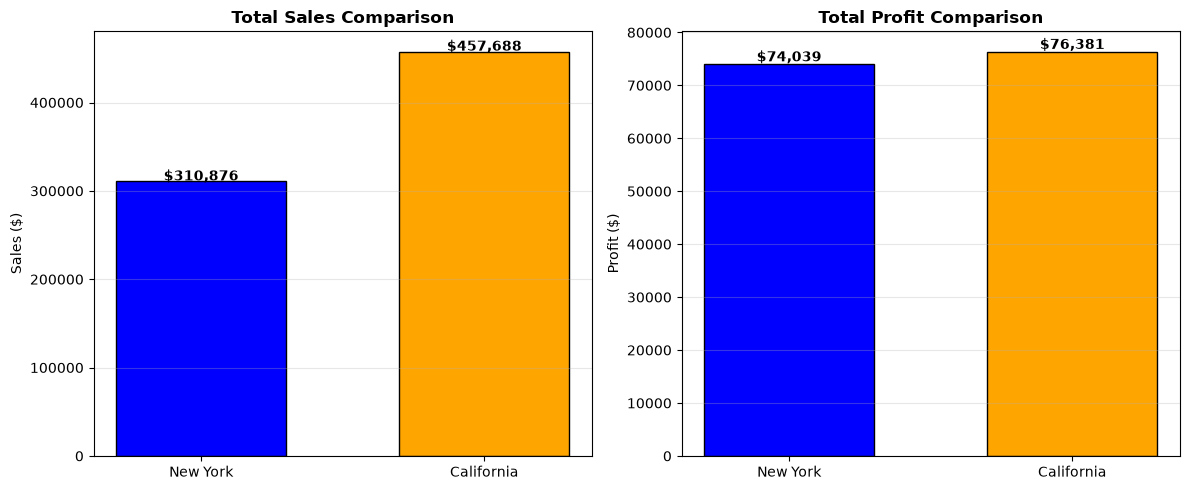

In [13]:
# Create comparison chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Sales comparison
states = ['New York', 'California']
sales = [ny_sales, ca_sales]
colors_sales = ['blue', 'orange']

ax1.bar(states, sales, color=colors_sales, edgecolor='black', width=0.6)
ax1.set_title('Total Sales Comparison', fontsize=12, fontweight='bold')
ax1.set_ylabel('Sales ($)')
ax1.grid(axis='y', alpha=0.3)

# Add values on bars
for i, v in enumerate(sales):
    ax1.text(i, v + 1000, f'${v:,.0f}', ha='center', fontweight='bold')

# Profit comparison
profits = [ny_profit, ca_profit]
colors_profit = ['blue', 'orange']

ax2.bar(states, profits, color=colors_profit, edgecolor='black', width=0.6)
ax2.set_title('Total Profit Comparison', fontsize=12, fontweight='bold')
ax2.set_ylabel('Profit ($)')
ax2.grid(axis='y', alpha=0.3)

# Add values on bars
for i, v in enumerate(profits):
    ax2.text(i, v + 500, f'${v:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Find an outstanding customer in New York

In [16]:
df = pd.read_excel('US Superstore data.xls')

# Filter for New York only
ny_data = df[df['State'] == 'New York']
top_orders_customer = ny_data.groupby('Customer Name').size().sort_values(ascending=False).head(1)
print("Top Customer by NUMBER OF ORDERS in New York:")
print(f"  Name: {top_orders_customer.index[0]}")
print(f"  Total Orders: {top_orders_customer.values[0]}")

top_sales_customer = ny_data.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(1)
print("Top Customer by SALES in New York:")
print(f"  Name: {top_sales_customer.index[0]}")
print(f"  Total Sales: ${top_sales_customer.values[0]:,.2f}\n")

Top Customer by NUMBER OF ORDERS in New York:
  Name: Seth Vernon
  Total Orders: 14
Top Customer by SALES in New York:
  Name: Tom Ashbrook
  Total Sales: $13,723.50



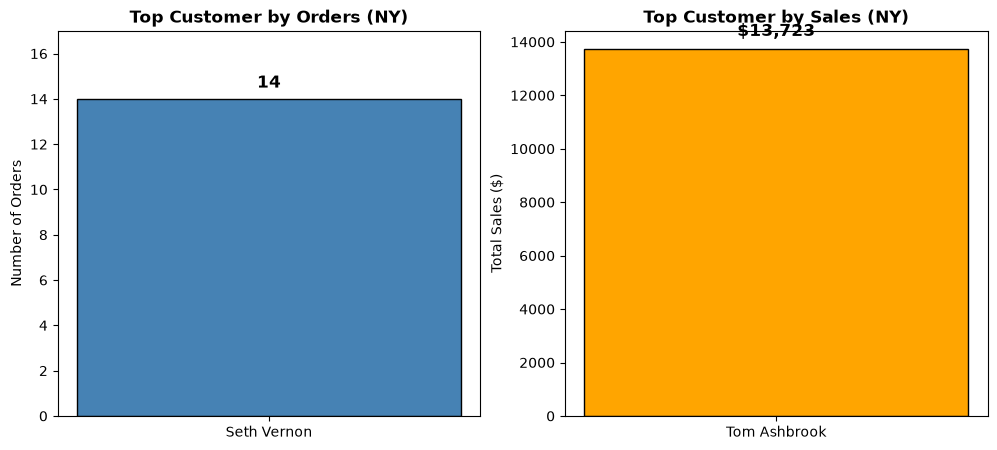

In [19]:

# Filter for New York only
ny_data = df[df['State'] == 'New York']

# Get top customer by orders
top_orders_customer = ny_data.groupby('Customer Name').size().sort_values(ascending=False).head(1)
orders_name = top_orders_customer.index[0]
orders_count = top_orders_customer.values[0]

# Get top customer by sales
top_sales_customer = ny_data.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(1)
sales_name = top_sales_customer.index[0]
sales_amount = top_sales_customer.values[0]

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Orders chart
ax1.bar([orders_name], [orders_count], color='steelblue', edgecolor='black', width=0.5)
ax1.set_ylabel('Number of Orders')
ax1.set_title('Top Customer by Orders (NY)', fontweight='bold')
ax1.text(0, orders_count + 0.5, f'{orders_count}', ha='center', fontweight='bold', fontsize=12)
ax1.set_ylim(0, orders_count + 3)

# Sales chart
ax2.bar([sales_name], [sales_amount], color='orange', edgecolor='black', width=0.5)
ax2.set_ylabel('Total Sales ($)')
ax2.set_title('Top Customer by Sales (NY)', fontweight='bold')
ax2.text(0, sales_amount + 500, f'${sales_amount:,.0f}', ha='center', fontweight='bold', fontsize=12)


plt.show()

Check for differences in profitability by state:

In [21]:
# Group by State and calculate profit metrics
state_profitability = df.groupby('State').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()

# Calculate profit margin (Profit / Sales * 100)
state_profitability['Profit Margin %'] = (state_profitability['Profit'] / state_profitability['Sales'] * 100).round(2)

# Sort by profit
state_profitability_sorted = state_profitability.sort_values('Profit', ascending=False)

print("\n" + "="*70)
print("PROFITABILITY BY STATE")
print("="*70)
print(f"{'State':<20} {'Total Sales':>15} {'Total Profit':>15} {'Margin %':>10}")
print("-"*70)

for _, row in state_profitability_sorted.iterrows():
    print(f"{row['State']:<20} ${row['Sales']:>13,.2f} ${row['Profit']:>13,.2f} {row['Profit Margin %']:>9.2f}%")

print("="*70)

# Find most and least profitable
most_profitable = state_profitability_sorted.iloc[0]
least_profitable = state_profitability_sorted.iloc[-1]

print(f"\nMOST PROFITABLE:  {most_profitable['State']} (${most_profitable['Profit']:,.2f})")
print(f"LEAST PROFITABLE: {least_profitable['State']} (${least_profitable['Profit']:,.2f})")
print(f"\nDifference: ${most_profitable['Profit'] - least_profitable['Profit']:,.2f}\n")


PROFITABILITY BY STATE
State                    Total Sales    Total Profit   Margin %
----------------------------------------------------------------------
California           $   457,687.63 $    76,381.39     16.69%
New York             $   310,876.27 $    74,038.55     23.82%
Washington           $   138,641.27 $    33,402.65     24.09%
Michigan             $    76,269.61 $    24,463.19     32.07%
Virginia             $    70,636.72 $    18,597.95     26.33%
Indiana              $    53,555.36 $    18,382.94     34.33%
Georgia              $    49,095.84 $    16,250.04     33.10%
Kentucky             $    36,591.75 $    11,199.70     30.61%
Minnesota            $    29,863.15 $    10,823.19     36.24%
Delaware             $    27,451.07 $     9,977.37     36.35%
New Jersey           $    35,764.31 $     9,772.91     27.33%
Wisconsin            $    32,114.61 $     8,401.80     26.16%
Rhode Island         $    22,627.96 $     7,285.63     32.20%
Maryland             $    23,705.52

Testig The Pareto Principle

In [24]:
# Step 1: Group by customer and sum profit
customer_profit = df.groupby('Customer Name')['Profit'].sum().reset_index()
customer_profit.columns = ['Customer Name', 'Profit']

# Step 2: Sort by profit (highest to lowest)
customer_profit_sorted = customer_profit.sort_values('Profit', ascending=False).reset_index(drop=True)

# Step 3: Calculate total profit
total_profit = customer_profit_sorted['Profit'].sum()

# Step 4: Calculate cumulative profit and percentage
customer_profit_sorted['Cumulative Profit'] = customer_profit_sorted['Profit'].cumsum()
customer_profit_sorted['Cumulative %'] = (customer_profit_sorted['Cumulative Profit'] / total_profit * 100).round(2)

# Step 5: Find how many customers contribute to 80% of profit
customers_for_80 = customer_profit_sorted[customer_profit_sorted['Cumulative %'] <= 80]
num_customers_for_80 = len(customers_for_80)

# Step 6: Calculate percentage of total customers
total_customers = len(customer_profit_sorted)
percentage_of_customers = round(num_customers_for_80 / total_customers * 100, 2)  # Fixed: use round() function

# Display results
print("\n" + "="*70)
print("PARETO PRINCIPLE ANALYSIS - CUSTOMERS & PROFIT")
print("="*70)
print(f"\nTotal Customers: {total_customers}")
print(f"Total Profit: ${total_profit:,.2f}")

print(f"\n📊 PARETO FINDINGS:")
print(f"   {num_customers_for_80} customers ({percentage_of_customers}%) contribute to ~80% of profit")

if percentage_of_customers <= 20:
    print(f"   ✓ YES! The Pareto Principle applies!")
    print(f"   ✓ {percentage_of_customers}% of customers generate 80% of profit")
else:
    print(f"   ✗ The Pareto Principle doesn't strictly apply")
    print(f"   ✗ It takes {percentage_of_customers}% of customers (not 20%) for 80% of profit")

print("\n" + "="*70)
print("TOP 10 CUSTOMERS BY PROFIT:")
print("="*70)
for idx, row in customer_profit_sorted.head(10).iterrows():
    print(f"{idx+1}. {row['Customer Name']:<25} ${row['Profit']:>10,.2f}  (Cumulative: {row['Cumulative %']:.1f}%)")

print("="*70 + "\n")


PARETO PRINCIPLE ANALYSIS - CUSTOMERS & PROFIT

Total Customers: 793
Total Profit: $286,397.02

📊 PARETO FINDINGS:
   152 customers (19.17%) contribute to ~80% of profit
   ✓ YES! The Pareto Principle applies!
   ✓ 19.17% of customers generate 80% of profit

TOP 10 CUSTOMERS BY PROFIT:
1. Tamara Chand              $  8,981.32  (Cumulative: 3.1%)
2. Raymond Buch              $  6,976.10  (Cumulative: 5.6%)
3. Sanjit Chand              $  5,757.41  (Cumulative: 7.6%)
4. Hunter Lopez              $  5,622.43  (Cumulative: 9.6%)
5. Adrian Barton             $  5,444.81  (Cumulative: 11.4%)
6. Tom Ashbrook              $  4,703.79  (Cumulative: 13.1%)
7. Christopher Martinez      $  3,899.89  (Cumulative: 14.4%)
8. Keith Dawkins             $  3,038.63  (Cumulative: 15.5%)
9. Andy Reiter               $  2,884.62  (Cumulative: 16.5%)
10. Daniel Raglin             $  2,869.08  (Cumulative: 17.5%)



What are the Top 20 cities by Sales ? What about the Top 20 cities by Profit ? Are there any difference among cities in profitability ? (Identify the top 20 cities based on total sales and total profit and analyze differences in profitability among these cities.)

In [25]:
# Group by city
city_data = df.groupby('City').agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index()
city_data['Margin %'] = (city_data['Profit'] / city_data['Sales'] * 100).round(2)

# Top 20 by Sales
print("\nTOP 20 CITIES BY SALES:")
print("="*60)
top_sales = city_data.sort_values('Sales', ascending=False).head(20)
for rank, (_, row) in enumerate(top_sales.iterrows(), 1):
    print(f"{rank}. {row['City']:<20} Sales: ${row['Sales']:>10,.0f}  Profit: ${row['Profit']:>8,.0f}")

# Top 20 by Profit
print("\nTOP 20 CITIES BY PROFIT:")
print("="*60)
top_profit = city_data.sort_values('Profit', ascending=False).head(20)
for rank, (_, row) in enumerate(top_profit.iterrows(), 1):
    print(f"{rank}. {row['City']:<20} Profit: ${row['Profit']:>10,.0f}  Margin: {row['Margin %']:.1f}%")


TOP 20 CITIES BY SALES:
1. New York City        Sales: $   256,368  Profit: $  62,037
2. Los Angeles          Sales: $   175,851  Profit: $  30,441
3. Seattle              Sales: $   119,541  Profit: $  29,156
4. San Francisco        Sales: $   112,669  Profit: $  17,507
5. Philadelphia         Sales: $   109,077  Profit: $ -13,838
6. Houston              Sales: $    64,505  Profit: $ -10,154
7. Chicago              Sales: $    48,540  Profit: $  -6,655
8. San Diego            Sales: $    47,521  Profit: $   6,377
9. Jacksonville         Sales: $    44,713  Profit: $  -2,324
10. Springfield          Sales: $    43,054  Profit: $   6,201
11. Detroit              Sales: $    42,447  Profit: $  13,182
12. Columbus             Sales: $    38,706  Profit: $   5,897
13. Newark               Sales: $    28,576  Profit: $   5,794
14. Columbia             Sales: $    25,283  Profit: $   5,606
15. Lafayette            Sales: $    25,036  Profit: $  10,018
16. Jackson              Sales: $    24

Who are the Top 20 customers by Sales?

In [26]:
# Group by customer and sum sales
customer_sales = df.groupby('Customer Name')['Sales'].sum().reset_index()

# Top 20 by Sales
print("\nTOP 20 CUSTOMERS BY SALES:")
print("="*60)
top_20 = customer_sales.sort_values('Sales', ascending=False).head(20)
for rank, (_, row) in enumerate(top_20.iterrows(), 1):
    print(f"{rank}. {row['Customer Name']:<25} ${row['Sales']:>12,.2f}")


TOP 20 CUSTOMERS BY SALES:
1. Sean Miller               $   25,043.05
2. Tamara Chand              $   19,052.22
3. Raymond Buch              $   15,117.34
4. Tom Ashbrook              $   14,595.62
5. Adrian Barton             $   14,473.57
6. Ken Lonsdale              $   14,175.23
7. Sanjit Chand              $   14,142.33
8. Hunter Lopez              $   12,873.30
9. Sanjit Engle              $   12,209.44
10. Christopher Conant        $   12,129.07
11. Todd Sumrall              $   11,891.75
12. Greg Tran                 $   11,820.12
13. Becky Martin              $   11,789.63
14. Seth Vernon               $   11,470.95
15. Caroline Jumper           $   11,164.97
16. Clay Ludtke               $   10,880.55
17. Maria Etezadi             $   10,663.73
18. Karen Ferguson            $   10,604.27
19. Bill Shonely              $   10,501.65
20. Edward Hooks              $   10,310.88


Plot the Cumulative curve in Sales by Customers. Can we apply Pareto principle to customers and Sales ?

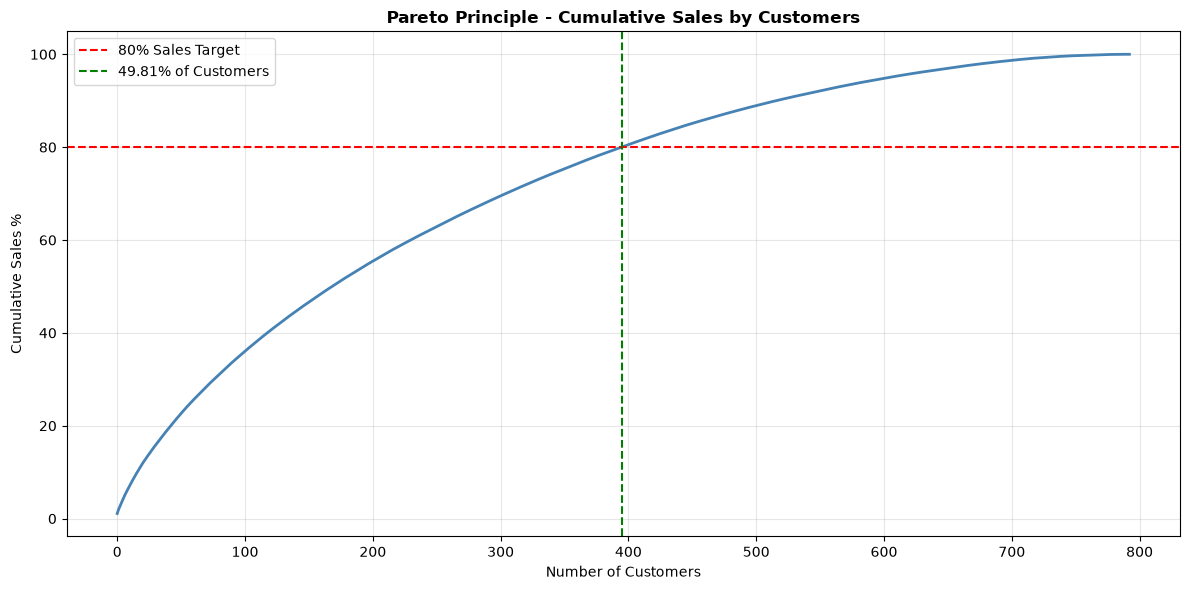


PARETO PRINCIPLE - CUSTOMERS & SALES
Total Customers: 793
Total Sales: $2,297,200.86

395 customers (49.81%) generate 80% of sales
✗ Takes 49.81% of customers (not 20%) for 80% of sales



In [27]:

# Group by customer and sum sales
customer_sales = df.groupby('Customer Name')['Sales'].sum().reset_index()
customer_sales_sorted = customer_sales.sort_values('Sales', ascending=False).reset_index(drop=True)

# Calculate cumulative sales and percentage
total_sales = customer_sales_sorted['Sales'].sum()
customer_sales_sorted['Cumulative Sales'] = customer_sales_sorted['Sales'].cumsum()
customer_sales_sorted['Cumulative %'] = (customer_sales_sorted['Cumulative Sales'] / total_sales * 100).round(2)

# Find customers for 80% of sales
customers_for_80 = len(customer_sales_sorted[customer_sales_sorted['Cumulative %'] <= 80])
total_customers = len(customer_sales_sorted)
percentage = round(customers_for_80 / total_customers * 100, 2)

# Plot cumulative curve
plt.figure(figsize=(12, 6))
plt.plot(range(len(customer_sales_sorted)), customer_sales_sorted['Cumulative %'], linewidth=2, color='steelblue')
plt.axhline(y=80, color='red', linestyle='--', label='80% Sales Target')
plt.axvline(x=customers_for_80, color='green', linestyle='--', label=f'{percentage}% of Customers')
plt.xlabel('Number of Customers')
plt.ylabel('Cumulative Sales %')
plt.title('Pareto Principle - Cumulative Sales by Customers', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Print Pareto Analysis
print("\n" + "="*60)
print("PARETO PRINCIPLE - CUSTOMERS & SALES")
print("="*60)
print(f"Total Customers: {total_customers}")
print(f"Total Sales: ${total_sales:,.2f}")
print(f"\n{customers_for_80} customers ({percentage}%) generate 80% of sales")

if percentage <= 20:
    print("✓ YES! Pareto Principle applies!")
else:
    print(f"✗ Takes {percentage}% of customers (not 20%) for 80% of sales")
print("="*60 + "\n")

Based on the analysis, make decisions on which states and cities to prioritize for marketing strategies.

In [28]:
# States
state_data = df.groupby('State').agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index()
state_data['Margin %'] = (state_data['Profit'] / state_data['Sales'] * 100).round(2)

# Cities
city_data = df.groupby('City').agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index()
city_data['Margin %'] = (city_data['Profit'] / city_data['Sales'] * 100).round(2)

print("\n" + "="*60)
print("MARKETING PRIORITIES")
print("="*60)

# High performers
print("\n✓ INVEST MORE (High Sales + Good Profit):")
high = state_data[state_data['Profit'] > state_data['Profit'].quantile(0.75)]
for _, row in high.iterrows():
    print(f"  {row['State']:<20} ${row['Profit']:>10,.0f} profit")

# Problem areas
print("\n✗ FIX THESE (Low Profit):")
low = state_data[state_data['Profit'] < state_data['Profit'].quantile(0.25)]
for _, row in low.iterrows():
    print(f"  {row['State']:<20} ${row['Profit']:>10,.0f} profit")

print("\n" + "="*60 + "\n")


MARKETING PRIORITIES

✓ INVEST MORE (High Sales + Good Profit):
  California           $    76,381 profit
  Delaware             $     9,977 profit
  Georgia              $    16,250 profit
  Indiana              $    18,383 profit
  Kentucky             $    11,200 profit
  Michigan             $    24,463 profit
  Minnesota            $    10,823 profit
  New Jersey           $     9,773 profit
  New York             $    74,039 profit
  Virginia             $    18,598 profit
  Washington           $    33,403 profit
  Wisconsin            $     8,402 profit

✗ FIX THESE (Low Profit):
  Arizona              $    -3,428 profit
  Colorado             $    -6,528 profit
  Florida              $    -3,399 profit
  Illinois             $   -12,608 profit
  North Carolina       $    -7,491 profit
  Ohio                 $   -16,971 profit
  Oregon               $    -1,190 profit
  Pennsylvania         $   -15,560 profit
  Tennessee            $    -5,342 profit
  Texas                $  